In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=0.72882357/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

Enter measurements for species

In [14]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            'NII':'<13.5',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',
            'FeII':'<11.4'}

Try out a new solution including sub-solar [C/O]

In [15]:
logN_HI_test = 16.67
log_hdens_test =  -2.9
log_metals_test = -2.6

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, 
                                     species_logN_interp, {'C':-0.45})

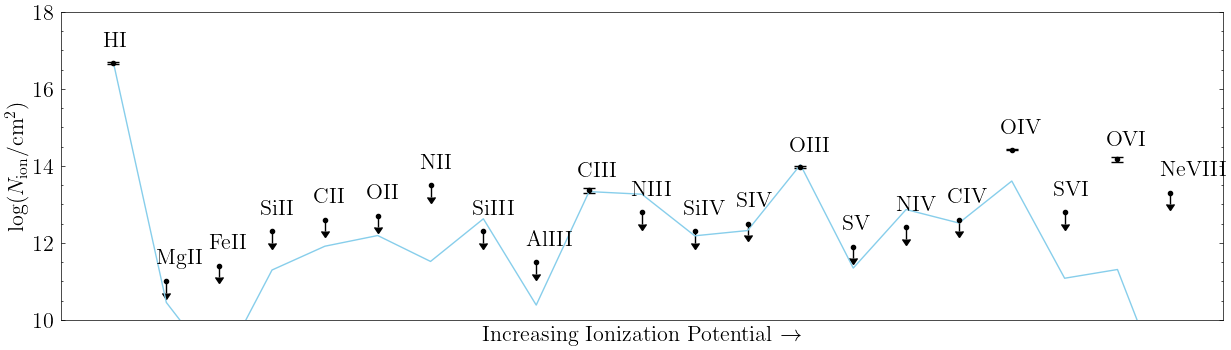

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Get column density ratios

In [24]:
gen_logN_ratio_str(logN_dict['CIII'], logN_dict['CIV'])

'>0.76, 0.16'

In [25]:
logN_ratio_dict = {#'OIV/OIII': '0.45, -0.04, 0.04',
                   'OIII/OII':'>1.3, 0.1',
                   'OIII/SIV': '>1.5, 0.1',
                   'OIII/SV': '>2.1, 0.1',
                   'CIII/CII':'>0.8, 0.2',
                   'CIII/CIV': '>0.8, 0.2'}

Generate predicted column density ratios

(0.0, 5.0)

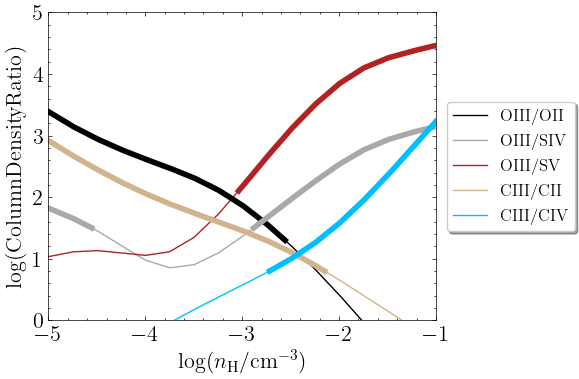

In [26]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict, 
                logN_HI_ref=12.5, log_metals_ref=-2.5)

ax.set_xlim(-5, -1)
ax.set_ylim(-0, 5)

# Fit gas density

In [27]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [28]:
logN_ratio_dict

{'OIII/OII': '>1.3, 0.1',
 'OIII/SIV': '>1.5, 0.1',
 'OIII/SV': '>2.1, 0.1',
 'CIII/CII': '>0.8, 0.2',
 'CIII/CIV': '>0.8, 0.2'}

In [29]:
pos = np.array(-2.6) + 1e-4 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [30]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [31]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [09:32<00:00,  1.15s/it]


In [32]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

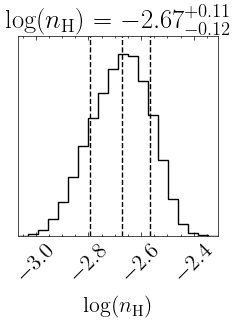

In [33]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [34]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [35]:
logN_offset = 13.97-np.mean(species_logN_interp['O+2'](grid_points_hdens))

Calculate the C/O ratio

In [39]:
logN_CIII_obs = np.random.normal(loc=13.36, scale=0.07, size=len(flat_samples_hdens))

In [40]:
C_O_dist_CIII = logN_CIII_obs-(logN_offset+species_logN_interp['C+2'](grid_points_hdens))
C_O_dist = C_O_dist_CIII

In [58]:
(np.round(np.median(C_O_dist), 2), 
np.round(np.percentile(C_O_dist, 100*(1-cdf_1sig))-np.median(C_O_dist), 2),
np.round(np.percentile(C_O_dist, 100*cdf_1sig)-np.median(C_O_dist), 2))

(-0.46, -0.14, 0.13)

Plot models

In [50]:
logN_dict = {#'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            #'NII':'<13.5',
            #'NIII':'<12.8',
            #'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            #'OVI':'14.17, -0.07, +0.07',
            #'NeVIII':'<13.3',
            'MgII':'<11.0',
            #'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            #'SVI':'<12.8',
            'FeII':'<11.4'}

In [51]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

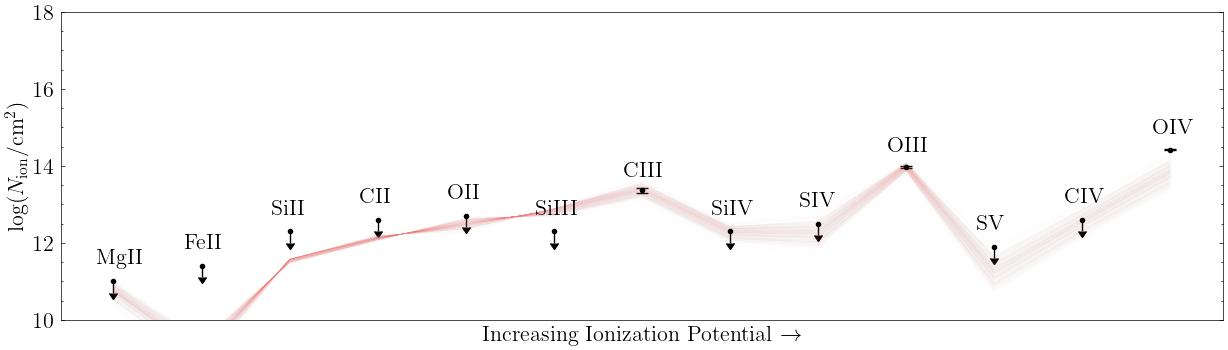

In [52]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.05)

# Oxygen + Sulphur fit

In [22]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if -4<log_hdens<-2 and log_metals_min<log_metals<log_metals_max:
        return 0.0
    return -np.inf

In [23]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [23]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [24]:
ions_oxy_sul = ['OII', 'OIII', 'SIV', 'SV']

In [25]:
logN_dict_oxy_sul = {ion: logN_dict[ion] for ion in ions_oxy_sul}

In [26]:
logN_dict_oxy_sul

{'OII': '<12.7', 'OIII': '13.97, -0.03, +0.03', 'SIV': '<12.5', 'SV': '<11.9'}

In [27]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [28]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy_sul, species_logN_interp)
)

In [29]:
sampler.run_mcmc(pos, 500, progress=True)

100%|███████████████████████████████████| 500/500 [03:45<00:00,  2.22it/s]


State([[-3.16633538 -2.89865014]
 [-2.90034114 -2.64278262]
 [-2.85855067 -2.63164646]
 [-3.06435859 -2.80479807]
 [-2.98728218 -2.78271837]
 [-2.75624528 -2.50448861]
 [-2.5146421  -2.30986084]
 [-2.93070169 -2.70887972]
 [-2.87462179 -2.64525965]
 [-2.58367694 -2.30908783]
 [-2.95585245 -2.72425687]
 [-2.65556998 -2.37895531]
 [-3.07140262 -2.81756885]
 [-2.64293925 -2.39399169]
 [-2.77380539 -2.55847532]
 [-2.75489031 -2.49966184]
 [-2.96564    -2.70362622]
 [-2.52806595 -2.26946696]
 [-2.53744682 -2.31656605]
 [-3.12013463 -2.89687051]
 [-3.21025118 -2.99674339]
 [-3.0932282  -2.8550959 ]
 [-2.91423975 -2.66036765]
 [-3.14058118 -2.94726621]
 [-2.73851008 -2.45727052]
 [-2.98097122 -2.77848783]
 [-2.67312905 -2.40437967]
 [-3.18323779 -2.98078377]
 [-2.65196937 -2.43530301]
 [-2.97719266 -2.70492982]
 [-3.01926317 -2.73703201]
 [-2.68888957 -2.45843396]
 [-2.97378735 -2.79945643]
 [-2.96619869 -2.72758929]
 [-3.0744952  -2.86687182]
 [-2.68561288 -2.42951967]
 [-2.97711765 -2.73553

In [33]:
#flat_samples_oxy_sul = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens', 'log_metals'])
#flat_samples_oxy_sul.to_csv(savedir+'oxy_sul_solar_flat.csv', index=False)

flat_samples_oxy_sul = pd.read_csv(savedir+'oxy_sul_solar_flat.csv')

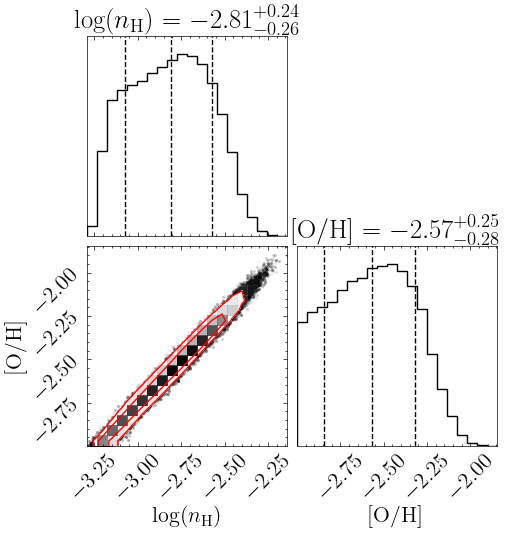

In [34]:
fig = corner.corner(
    flat_samples_oxy_sul.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [35]:
np.percentile(flat_samples_oxy_sul['log_metals'], 100*cdf_3sig)

-2.007894180745396

Now plot the best models

In [36]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            'NII':'<13.5',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',
            'FeII':'<11.4'}

In [37]:
sample_indices_oxy_sul = np.random.randint(low=0, high=len(flat_samples_oxy_sul), size=200)

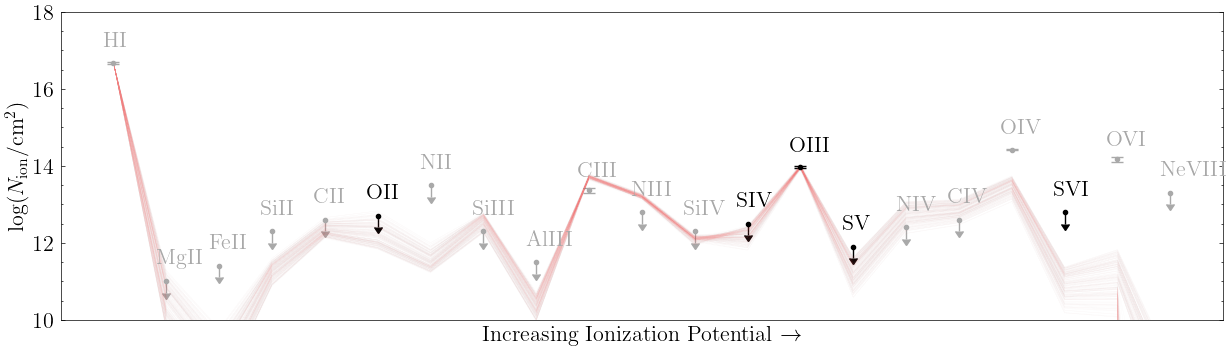

In [38]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CII', 'CIII', 
                                                         'CIV', 'NII', 'NIII', 'NIV',
                                                         'NeVIII', 'MgII', 
                                                         'AlIII', 'SiII', 'SiIII', 'SiIV', 
                                                         'FeII', 'OIV', 'OVI'])

for i in range(len(sample_indices_oxy_sul)):
    
    idx = sample_indices_oxy_sul[i]
    flat_samples_row = flat_samples_oxy_sul.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

Plot the posterior for cloud size

In [39]:
#flat_samples_oxy_sul['logN_HII'] = [species_logN_interp['H+']([logN_HI_test,
#                                                            flat_samples_oxy_sul.iloc[i]['log_hdens'],
#                                                            flat_samples_oxy_sul.iloc[i]['log_metals']])[0]
#                                               for i in range(len(flat_samples_oxy_sul))]

In [40]:
#flat_samples_oxy_sul['cloud_size_kpc'] = ((10**logN_HI_test+10**flat_samples_oxy_sul['logN_HII'])/10**flat_samples_oxy_sul['log_hdens'])*3.24078e-19*1e-3

In [42]:
#flat_samples_oxy_sul.to_csv(savedir+'oxy_sul_solar_flat.csv', index=False)

In [43]:
l_med = np.median(flat_samples_oxy_sul['cloud_size_kpc'])
l_perc_16 = np.percentile(flat_samples_oxy_sul['cloud_size_kpc'],16)
l_perc_84 = np.percentile(flat_samples_oxy_sul['cloud_size_kpc'],84)

In [44]:
l_med, l_med-l_perc_16, l_perc_84-l_med

(20.384133684892436, 14.33732796106714, 57.75722326910622)

In [45]:
np.percentile(flat_samples_oxy_sul['cloud_size_kpc'],100*cdf_3sig)

199.0587337551194

Text(0, 0.5, 'Probability Density')

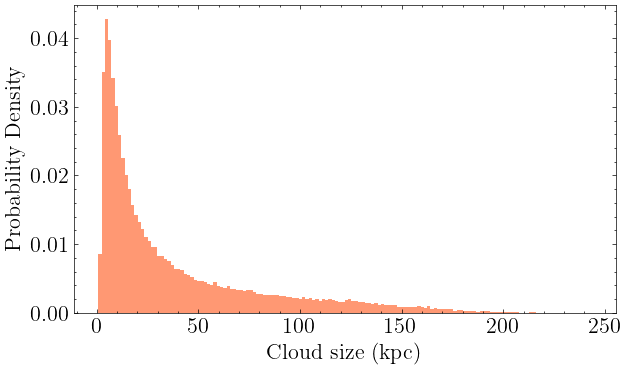

In [46]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_oxy_sul['cloud_size_kpc'], bins=150, density=True, color='coral', alpha=.8)
#ax.axvline(l_med, linestyle=':', lw=2)
#ax.axvline(l_perc_16, linestyle=':', lw=2)
#ax.axvline(l_perc_84, linestyle=':', lw=2)

#ax.text(140, 0.03, s=r'$\log N_{\mathrm{HI}} = 16.64 \pm 0.01$')
#ax.text(140, 0.022, s=r'$l < 200 \ \mathrm{kpc}$')

ax.set_xlabel('Cloud size (kpc)')
ax.set_ylabel('Probability Density')

# Oxygen + Sulphur + Carbon

In [47]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals, C_O = params
    
    # Get abundance for carbon
    C_H = log_metals + C_O
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if -4<log_hdens<-2 and log_metals_min<log_metals<log_metals_max and log_metals_min<C_H<log_metals_max:
        return 0.0
    return -np.inf

In [48]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals, C_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {'C': C_O}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [49]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [50]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            'NII':'<13.5',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',
            'FeII':'<11.4'}

In [51]:
ions_oxy_sul_carb = ['OII', 'OIII', 'SIV', 'SV', 'CII', 'CIII']

In [52]:
logN_dict_oxy_sul_carb = {ion: logN_dict[ion] for ion in ions_oxy_sul_carb}

In [53]:
logN_dict_oxy_sul_carb

{'OII': '<12.7',
 'OIII': '13.97, -0.03, +0.03',
 'SIV': '<12.5',
 'SV': '<11.9',
 'CII': '<12.6',
 'CIII': '13.36, -0.07, +0.07'}

In [55]:
pos = np.array([log_hdens_test, log_metals_test, -0.4]) + 1e-4 * np.random.randn(500, 3)
nwalkers, ndim = pos.shape

In [56]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy_sul_carb, species_logN_interp)
)

In [57]:
sampler.run_mcmc(pos, 500, progress=True)

  0%|                                             | 0/500 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████| 500/500 [05:06<00:00,  1.63it/s]


State([[-2.62645928 -2.35776275 -0.37128216]
 [-2.73889778 -2.46583243 -0.42102055]
 [-2.66978067 -2.46325373 -0.31388263]
 ...
 [-2.71446071 -2.47150373 -0.37069165]
 [-2.54831983 -2.27313387 -0.30409376]
 [-2.69363832 -2.46421867 -0.23439752]], log_prob=[ -4.43694269  -4.76891187  -5.21398205  -4.6119521   -4.5417973
  -4.24237301  -5.16564975  -5.2048928   -5.42267167  -4.34173053
  -4.86998771  -4.24419105  -6.45912227  -5.92731589  -6.15244457
  -4.22192637  -4.90691338  -5.64612228  -4.72911149  -6.64053613
  -4.47080332  -5.04078308  -4.50499358  -5.94931394  -5.03476246
  -5.55266312  -7.22845779  -4.96468072  -5.34927471  -4.69380296
  -4.23496973  -5.10443765  -8.36797348  -5.60581158  -5.87521415
  -4.53694945  -5.65081268  -4.60189085  -5.81922175  -6.34200358
  -6.78481284  -4.77107103  -5.02146637  -6.29493237  -5.57617629
  -4.34365082  -5.58719313  -4.83677471  -4.31774205  -4.79120555
  -4.52524961  -5.75126963  -4.22367043  -4.86649719  -4.39126682
  -4.28372006  -4.3

In [59]:
#flat_samples_oxy_sul_carb = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens', 'log_metals', 'C_O'])
#flat_samples_oxy_sul_carb.to_csv(savedir+'oxy_sul_carb_subsolar_flat.csv', index=False)

flat_samples_oxy_sul_carb = pd.read_csv(savedir+'oxy_sul_carb_subsolar_flat.csv')

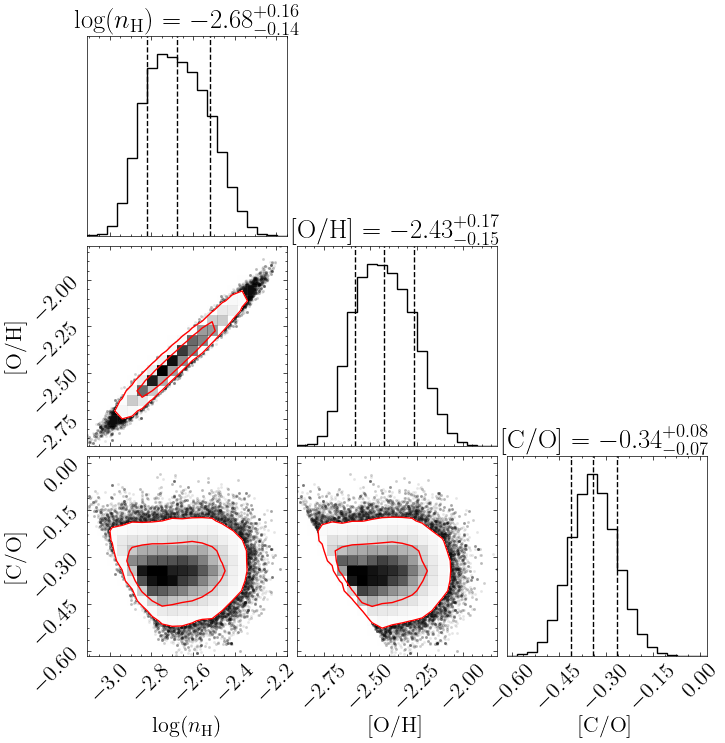

In [60]:
fig = corner.corner(
    flat_samples_oxy_sul_carb, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$', r'$[\mathrm{C/O}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Try out a new solution including sub-solar [C/O]

In [118]:
logN_HI_test = 16.67
log_hdens_test =  -3.25
log_metals_test = -2.54

In [119]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, species_logN_interp,
                                    {'C':-0.45})

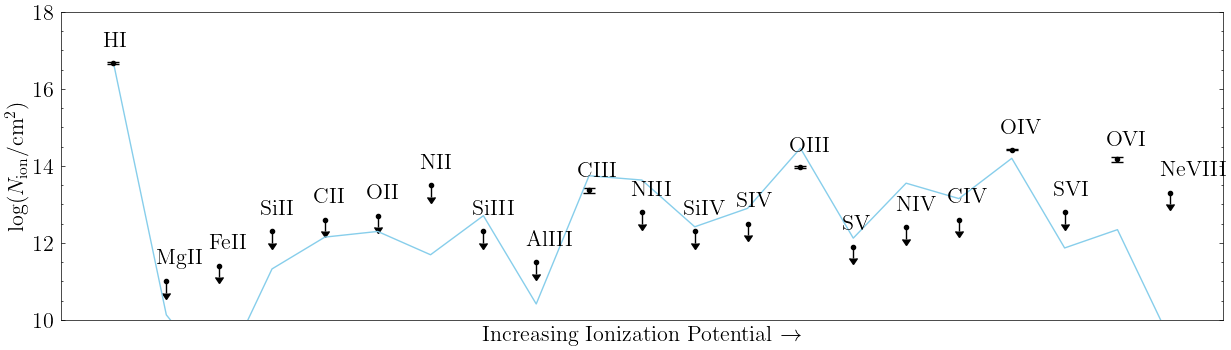

In [120]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Now plot the best models

In [61]:
logN_dict = {'HI':'16.67, -0.02, +0.02',
            'CII':'<12.6',
            'CIII':'13.36, -0.07, +0.07',
            'CIV':'<12.6',
            'NII':'<13.5',
            'NIII':'<12.8',
            'NIV':'<12.4',
            'OII':'<12.7',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'OVI':'14.17, -0.07, +0.07',
            'NeVIII':'<13.3',
            'MgII':'<11.0',
            'AlIII':'<11.5',
            'SiII':'<12.3',
            'SiIII':'<12.3',
            'SiIV':'<12.3',
            'SIV':'<12.5',
            'SV':'<11.9',
            'SVI':'<12.8',
            'FeII':'<11.4'}

In [62]:
sample_indices_oxy_sul_carb = np.random.randint(low=0, high=len(flat_samples_oxy_sul_carb), size=200)

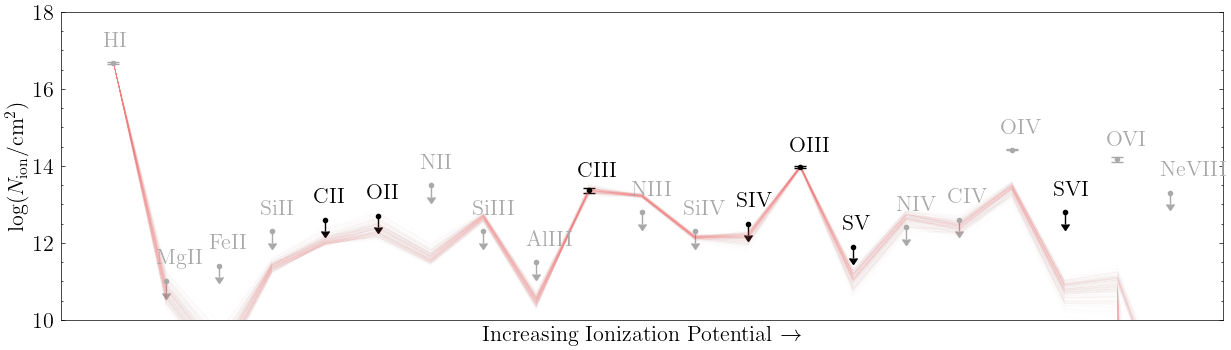

In [77]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CIV', 'NII', 'NIII', 'NIV',
                                                         'NeVIII', 'MgII', 
                                                         'AlIII', 'SiII', 'SiIII', 'SiIV', 
                                                         'FeII', 'OIV', 'OVI'])

for i in range(len(sample_indices_oxy_sul_carb)):
    
    idx = sample_indices_oxy_sul_carb[i]
    flat_samples_row = flat_samples_oxy_sul_carb.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    C_O = flat_samples_row['C_O']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp, {'C': C_O})
    
    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

Plot the posterior for cloud size

In [64]:
#flat_samples_oxy_sul_carb['logN_HII'] = [species_logN_interp['H+']([logN_HI_test,
#                                                            flat_samples_oxy_sul_carb.iloc[i]['log_hdens'],
#                                                            flat_samples_oxy_sul_carb.iloc[i]['log_metals']])[0]
#                                               for i in range(len(flat_samples_oxy_sul_carb))]

In [65]:
#flat_samples_oxy_sul_carb['cloud_size_kpc'] = ((10**logN_HI_test+10**flat_samples_oxy_sul_carb['logN_HII'])/10**flat_samples_oxy_sul_carb['log_hdens'])*3.24078e-19*1e-3

In [67]:
#flat_samples_oxy_sul_carb.to_csv(savedir+'oxy_sul_carb_subsolar_flat.csv', index=False)

In [73]:
l_med = np.median(flat_samples_oxy_sul_carb['cloud_size_kpc'])
l_perc_16 = np.percentile(flat_samples_oxy_sul_carb['cloud_size_kpc'],16)
l_perc_84 = np.percentile(flat_samples_oxy_sul_carb['cloud_size_kpc'],84)

In [74]:
l_med, l_med-l_perc_16, l_perc_84-l_med

(10.351958198290964, 5.738431742689879, 11.203964842542964)

In [75]:
np.percentile(flat_samples_oxy_sul_carb['cloud_size_kpc'],100*cdf_3sig)

57.66707442182824

Text(0, 0.5, 'Probability Density')

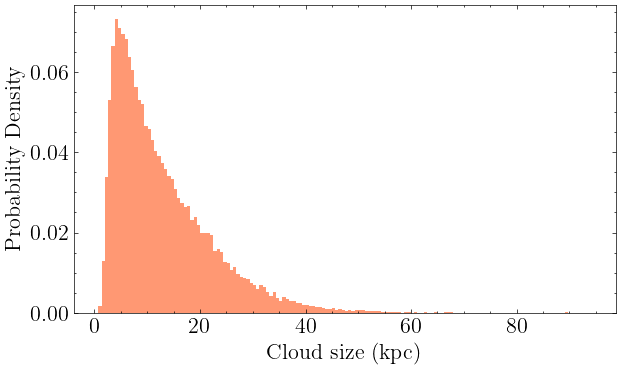

In [76]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_oxy_sul_carb['cloud_size_kpc'], bins=150, density=True, color='coral', alpha=.8)
#ax.axvline(l_med, linestyle=':', lw=2)
#ax.axvline(l_perc_16, linestyle=':', lw=2)
#ax.axvline(l_perc_84, linestyle=':', lw=2)

#ax.text(140, 0.03, s=r'$\log N_{\mathrm{HI}} = 16.64 \pm 0.01$')
#ax.text(140, 0.022, s=r'$l < 200 \ \mathrm{kpc}$')

ax.set_xlabel('Cloud size (kpc)')
ax.set_ylabel('Probability Density')